# Future-Work Roadmap Slide
Renders the final pitch slide as a high-DPI PNG. Run all cells; output is `future_work_slide.png`.

saved  future_work_slide.png


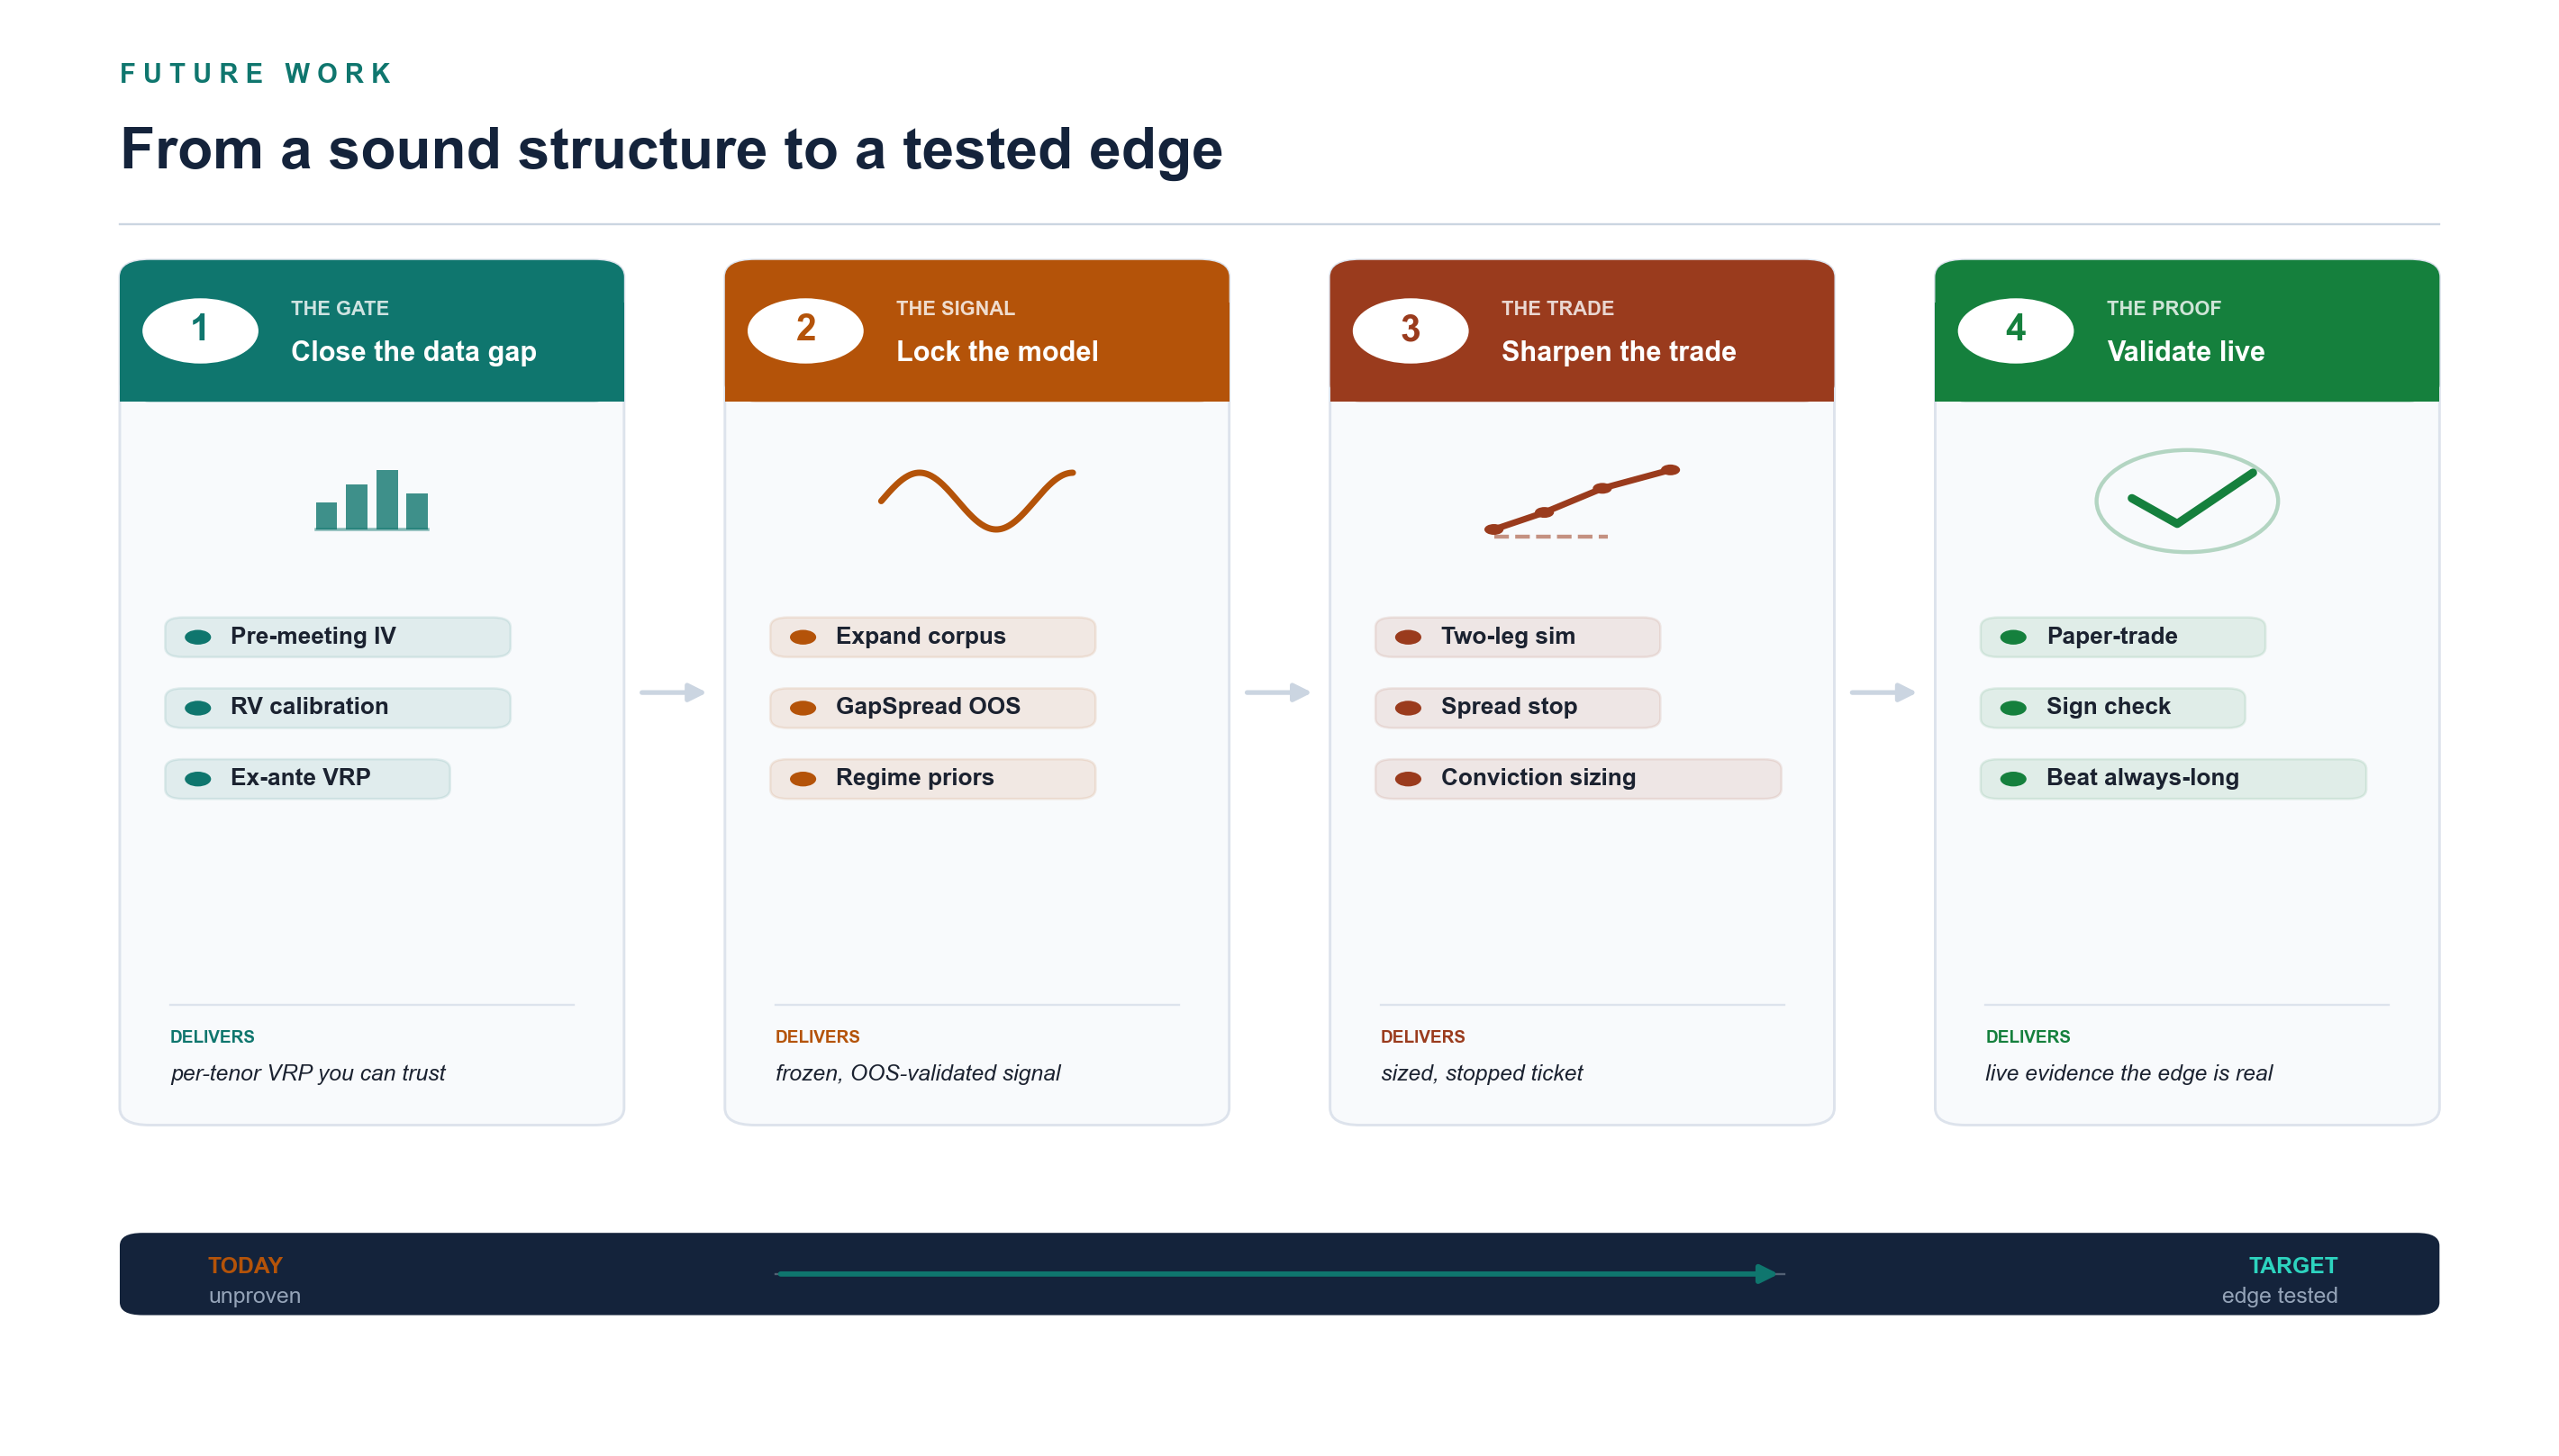

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Circle

# ── Palette ────────────────────────────────────────────────────────────────────
INK   = "#14233B"; TEAL  = "#0F766E"; AMBER = "#B45309"
CORAL = "#9A3B1D"; GREEN = "#15803D"
PAPER = "#FFFFFF"; TX    = "#1B2230"; MUTE  = "#64748B"
FAINT = "#CBD5E1"; LIGHT = "#F8FAFC"

# ── Arial font ─────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":     "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica Neue", "Helvetica", "DejaVu Sans"],
})

fig = plt.figure(figsize=(13.33, 7.5), dpi=210)
ax  = fig.add_axes([0, 0, 1, 1])
ax.set_xlim(0, 100); ax.set_ylim(0, 100); ax.axis("off")
fig.patch.set_facecolor(PAPER)

# ── Header ─────────────────────────────────────────────────────────────────────
ax.text(4, 95.5, "F U T U R E   W O R K",
        fontsize=10, color=TEAL, fontweight="bold")
ax.text(4, 89.5, "From a sound structure to a tested edge",
        fontsize=22, color=INK, fontweight="bold")
ax.plot([4, 96], [85.5, 85.5], color=FAINT, lw=0.8)

# ── Phase data (short chip labels, no prose) ───────────────────────────────────
phases = [
    dict(c=TEAL,  n="1", tag="THE GATE",   title="Close the data gap",
         chips=["Pre-meeting IV", "RV calibration", "Ex-ante VRP"],
         delivers="per-tenor VRP you can trust"),
    dict(c=AMBER, n="2", tag="THE SIGNAL", title="Lock the model",
         chips=["Expand corpus", "GapSpread OOS", "Regime priors"],
         delivers="frozen, OOS-validated signal"),
    dict(c=CORAL, n="3", tag="THE TRADE",  title="Sharpen the trade",
         chips=["Two-leg sim", "Spread stop", "Conviction sizing"],
         delivers="sized, stopped ticket"),
    dict(c=GREEN, n="4", tag="THE PROOF",  title="Validate live",
         chips=["Paper-trade", "Sign check", "Beat always-long"],
         delivers="live evidence the edge is real"),
]

x0, w, gap = 4.0, 20.0, 4.0
ytop, ybot = 83.0, 22.0

# ── Icon drawing helpers ────────────────────────────────────────────────────────
def icon_bars(ax, cx, cy, color):
    """4-bar chart (data gate)."""
    hs = [0.45, 0.75, 1.00, 0.60]; bw = 0.85
    span = len(hs)*bw + (len(hs)-1)*0.35
    for i, h in enumerate(hs):
        xi = cx - span/2 + i*(bw+0.35)
        ax.add_patch(FancyBboxPatch((xi, cy-2.0), bw, h*4.2,
                     boxstyle="square,pad=0", facecolor=color, alpha=0.80,
                     linewidth=0, zorder=5))
    ax.plot([cx-span/2, cx+span/2], [cy-2.0, cy-2.0], color=color, lw=1.2, alpha=0.5, zorder=5)

def icon_wave(ax, cx, cy, color):
    """Sine wave (signal)."""
    t  = np.linspace(0, 2.5*np.pi, 200)
    xs = cx - 3.8 + t/(2.5*np.pi)*7.6
    ys = cy + np.sin(t)*2.0
    ax.plot(xs, ys, color=color, lw=2.4, solid_capstyle="round", zorder=5)

def icon_chart(ax, cx, cy, color):
    """Ascending line + stop bar (trade)."""
    px = [cx-3.5, cx-1.5, cx+0.8, cx+3.5]
    py = [cy-2.0, cy-0.8, cy+0.9, cy+2.2]
    ax.plot(px, py, color=color, lw=2.4, solid_capstyle="round", zorder=5)
    for xi, yi in zip(px, py):
        ax.add_patch(Circle((xi, yi), 0.38, facecolor=color, edgecolor="none", zorder=6))
    ax.plot([cx-3.5, cx+1.0], [cy-2.5, cy-2.5], color=color, lw=1.5, ls="--", alpha=0.55, zorder=5)

def icon_check(ax, cx, cy, color):
    """Checkmark in a ring (proof)."""
    ax.add_patch(Circle((cx, cy), 3.6, fill=False, edgecolor=color, lw=1.5, alpha=0.30, zorder=4))
    px = [cx-2.2, cx-0.4, cx+2.6]
    py = [cy+0.2, cy-1.6, cy+2.0]
    ax.plot(px, py, color=color, lw=3.2, solid_capstyle="round", solid_joinstyle="round", zorder=5)

icon_fns = [icon_bars, icon_wave, icon_chart, icon_check]

def draw_chip(ax, x, y, text, color, card_w=20.0):
    """Chip label: colored border, light fill, short text."""
    chip_h = 2.8
    chip_w = min(card_w - 3.5, len(text)*0.80 + 2.5)
    ax.add_patch(FancyBboxPatch((x, y), chip_w, chip_h,
                 boxstyle="round,pad=0,rounding_size=0.7",
                 facecolor=color, alpha=0.10,
                 edgecolor=color, linewidth=0.9, zorder=5))
    ax.add_patch(Circle((x+1.3, y+chip_h/2), 0.52, facecolor=color, linewidth=0, zorder=6))
    ax.text(x+2.6, y+chip_h/2, text, fontsize=9.0, color=TX,
            fontweight="bold", va="center", zorder=7)

# ── Draw cards ─────────────────────────────────────────────────────────────────
for i, p in enumerate(phases):
    x = x0 + i*(w+gap)
    c = p["c"]

    # Card body
    ax.add_patch(FancyBboxPatch((x, ybot), w, ytop-ybot,
                 boxstyle="round,pad=0,rounding_size=1.2",
                 linewidth=1.0, edgecolor="#DDE3EC", facecolor=LIGHT, zorder=2))

    # Coloured header band (round top, square bottom)
    hb = 10.0
    ax.add_patch(FancyBboxPatch((x, ytop-hb), w, hb,
                 boxstyle="round,pad=0,rounding_size=1.2",
                 linewidth=0, facecolor=c, zorder=3))
    ax.add_patch(FancyBboxPatch((x, ytop-hb), w, hb-3.0,
                 boxstyle="square,pad=0",
                 linewidth=0, facecolor=c, zorder=3))

    # Number badge
    ax.add_patch(Circle((x+3.2, ytop-hb/2), 2.3, facecolor=PAPER, edgecolor="none", zorder=5))
    ax.text(x+3.2, ytop-hb/2, p["n"], ha="center", va="center",
            fontsize=14, fontweight="bold", color=c, zorder=6)

    # Tag + phase title in header
    ax.text(x+6.8, ytop-hb/2+1.5, p["tag"],
            fontsize=7.5, color=PAPER, fontweight="bold", va="center", alpha=0.80, zorder=6)
    ax.text(x+6.8, ytop-hb/2-1.6, p["title"],
            fontsize=10.5, color=PAPER, fontweight="bold", va="center", zorder=6)

    # Icon (centre of the icon zone)
    icon_cy = ytop - hb - 7.0
    icon_fns[i](ax, x + w/2, icon_cy, c)

    # Chips
    chip_x = x + 1.8
    for j, chip in enumerate(p["chips"]):
        chip_y = ytop - hb - 18.0 - j*5.0
        draw_chip(ax, chip_x, chip_y, chip, c)

    # Delivers section
    div_y = ybot + 8.5
    ax.plot([x+2.0, x+w-2.0], [div_y, div_y], color="#DDE3EC", lw=0.8, zorder=4)
    ax.text(x+2.0, div_y-1.8, "DELIVERS", fontsize=6.5, color=c, fontweight="bold", va="top")
    ax.text(x+2.0, div_y-4.2, p["delivers"], fontsize=8.5, color=TX, style="italic", va="top")

# ── Gating arrows ──────────────────────────────────────────────────────────────
mid_y = (ytop + ybot) / 2
for i in range(3):
    xa = x0 + i*(w+gap) + w + 0.5
    xb = xa + gap - 1.0
    ax.add_patch(FancyArrowPatch((xa, mid_y), (xb, mid_y),
                 arrowstyle="-|>", mutation_scale=14,
                 linewidth=1.8, color=FAINT, zorder=4))

# ── Maturity ribbon ─────────────────────────────────────────────────────────────
ry, rh = 11.5, 5.8
ax.add_patch(FancyBboxPatch((4, ry-rh/2), 92, rh,
             boxstyle="round,pad=0,rounding_size=0.9",
             linewidth=0, facecolor=INK, zorder=2))

# Arrow spine
ax.add_patch(FancyArrowPatch((30, ry), (70, ry),
             arrowstyle="-|>", mutation_scale=14,
             linewidth=2.0, color=TEAL, zorder=4))
ax.plot([30, 70], [ry, ry], color=FAINT, lw=0.8, alpha=0.35, zorder=3)

ax.text(7.5, ry+0.5, "TODAY",      fontsize=8.5, color=AMBER,    fontweight="bold", va="center")
ax.text(7.5, ry-1.6, "unproven",   fontsize=8.5, color="#94A3B8", va="center")
ax.text(92,  ry+0.5, "TARGET",     fontsize=8.5, color="#2DD4BF", fontweight="bold", va="center", ha="right")
ax.text(92,  ry-1.6, "edge tested",fontsize=8.5, color="#94A3B8", va="center", ha="right")

fig.savefig("future_work_slide.png", dpi=210,
            facecolor=PAPER, bbox_inches="tight", pad_inches=0.12)
print("saved  future_work_slide.png")

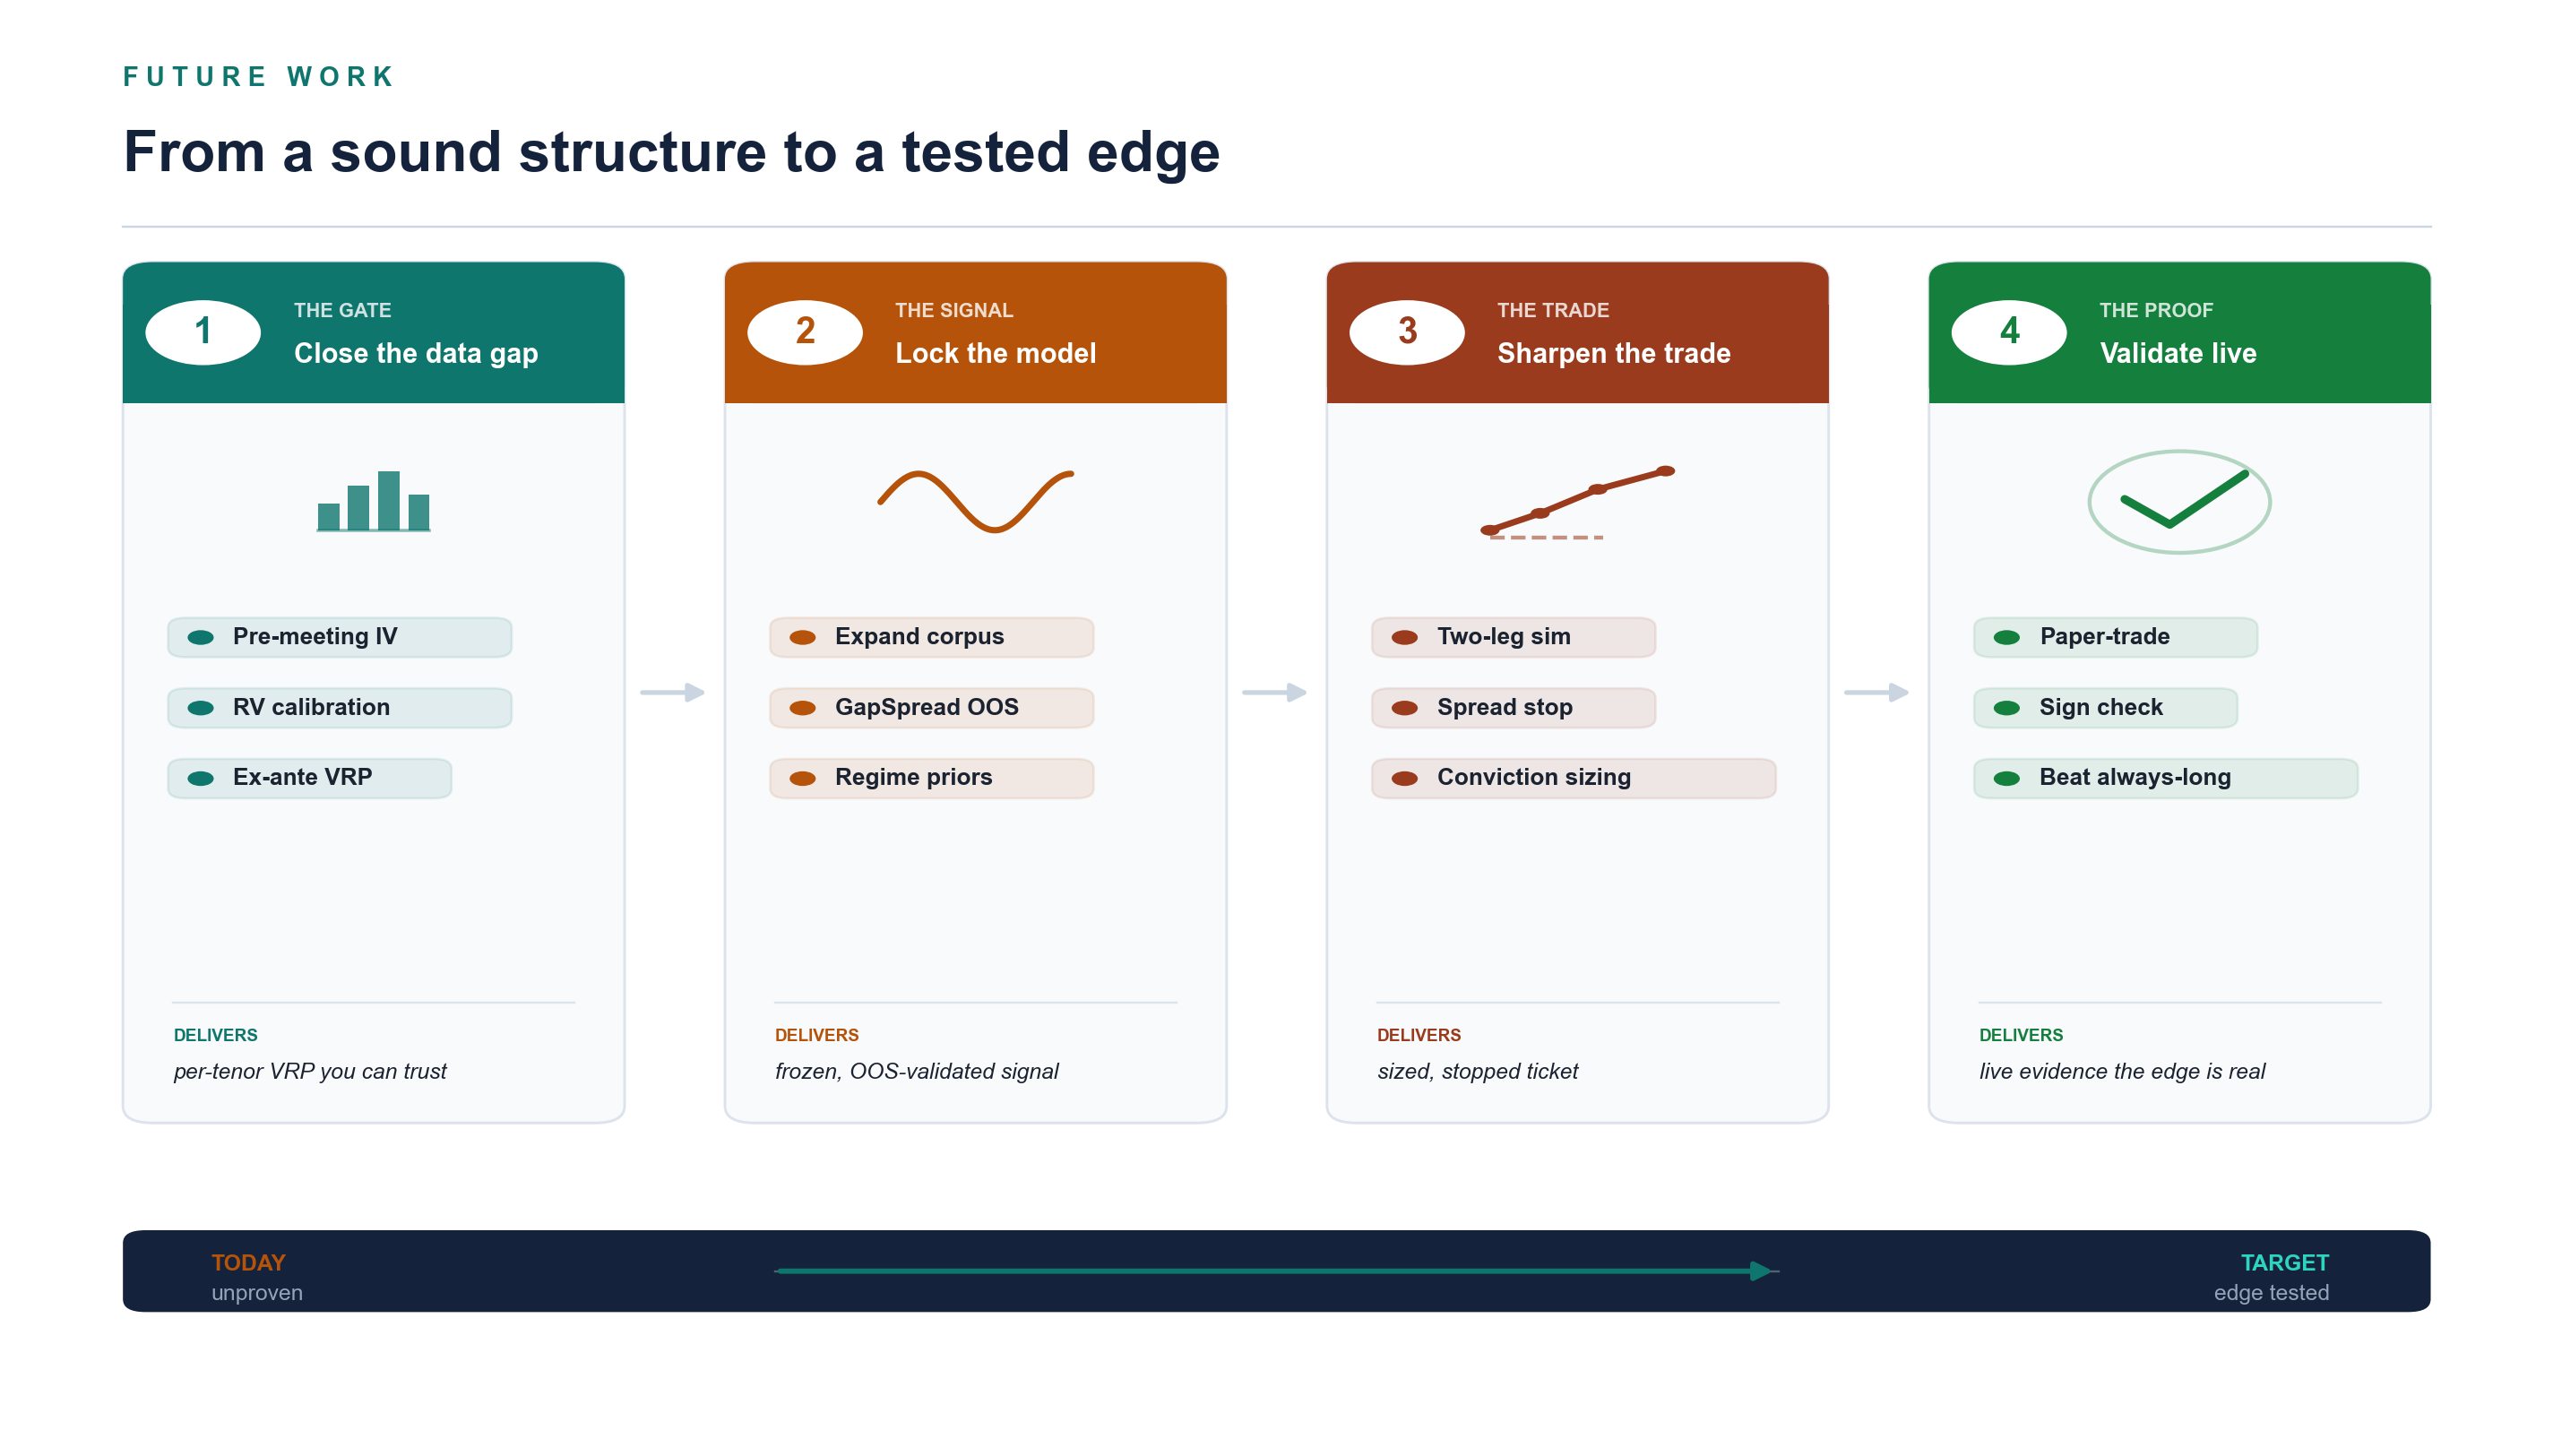

In [2]:
from IPython.display import Image
Image("future_work_slide.png")